In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as LeDucAnh

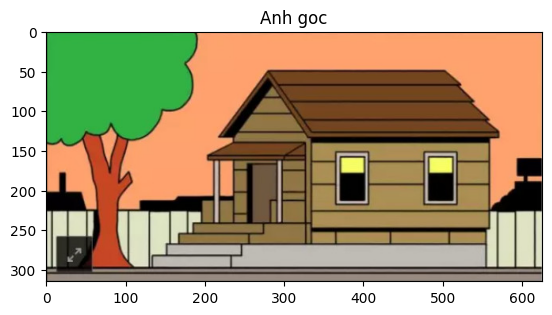

In [11]:
img = cv2.imread('hinh1.jpg')

LeDucAnh.imshow(img[:,:,::-1])
LeDucAnh.title("Anh goc")
LeDucAnh.show()

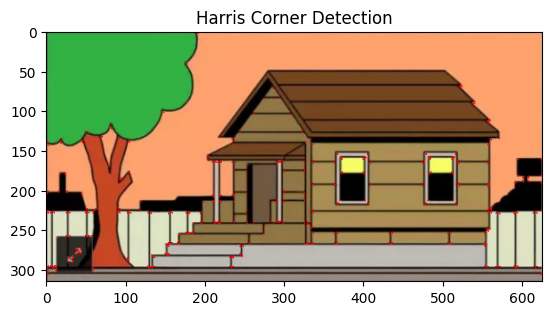

In [12]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

dst = cv2.cornerHarris(gray,2,3,0.04)

img[dst>0.01*dst.max()] = [0,0,255]

LeDucAnh.imshow(img[:,:,::-1])
LeDucAnh.title("Harris Corner Detection")
LeDucAnh.show()

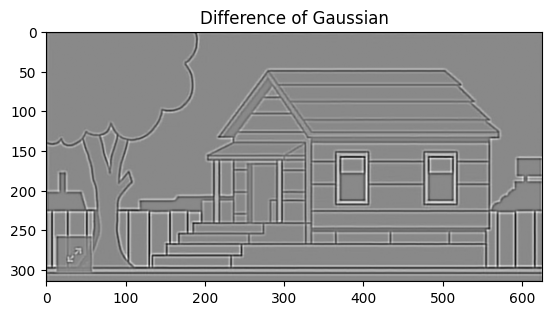

In [30]:
g1 = cv2.GaussianBlur(gray,(5,5),1)
g2 = cv2.GaussianBlur(gray,(5,5),2)

dog = g1 - g2

LeDucAnh.imshow(dog,cmap='gray')
LeDucAnh.title("Difference of Gaussian")
LeDucAnh.show()

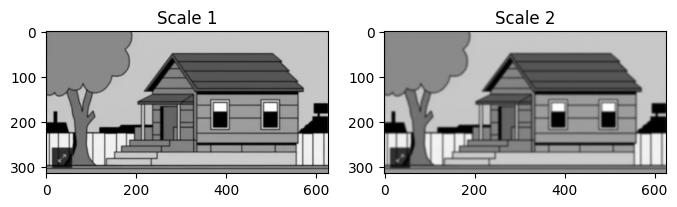

In [31]:
scale1 = cv2.GaussianBlur(gray,(3,3),1)
scale2 = cv2.GaussianBlur(gray,(7,7),2)

LeDucAnh.figure(figsize=(8,4))

LeDucAnh.subplot(1,2,1)
LeDucAnh.imshow(scale1,cmap='gray')
LeDucAnh.title("Scale 1")

LeDucAnh.subplot(1,2,2)
LeDucAnh.imshow(scale2,cmap='gray')
LeDucAnh.title("Scale 2")

LeDucAnh.show()

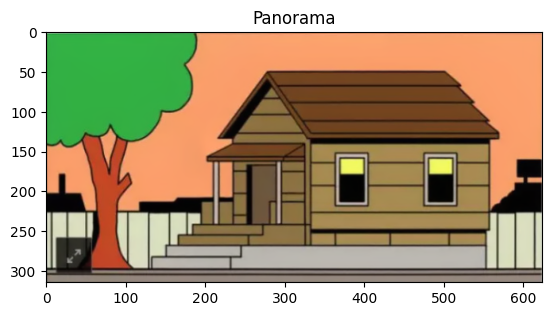

In [32]:
img = cv2.imread('hinh1.jpg')

img1 = img[:, :400]
img2 = img[:, 200:]

stitcher = cv2.Stitcher_create()
status, pano = stitcher.stitch([img1, img2])

if status == cv2.Stitcher_OK:
    LeDucAnh.imshow(pano[:,:,::-1])
    LeDucAnh.title("Panorama")
    LeDucAnh.show()
else:
    print("Stitch failed:", status)

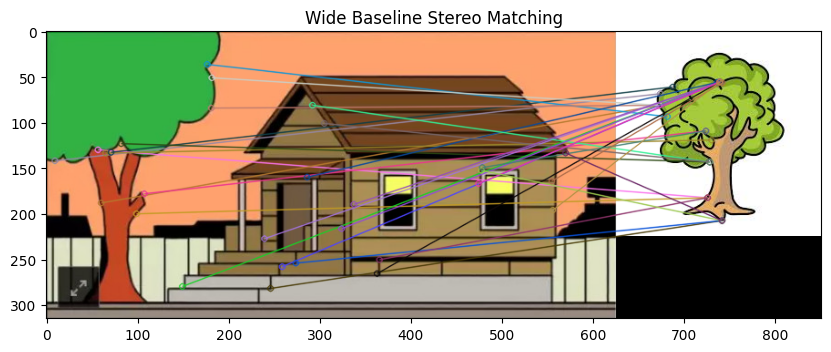

In [33]:
img1 = cv2.imread('hinh1.jpg')
img2 = cv2.imread('hinh2.jpg')

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1,None)
kp2, des2 = sift.detectAndCompute(gray2,None)

bf = cv2.BFMatcher()

matches = bf.knnMatch(des1,des2,k=2)

good = []

for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append(m)

result = cv2.drawMatches(
    img1,kp1,
    img2,kp2,
    good,None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

LeDucAnh.figure(figsize=(10,5))
LeDucAnh.imshow(result[:,:,::-1])
LeDucAnh.title("Wide Baseline Stereo Matching")
LeDucAnh.show()

In [34]:
img1 = cv2.imread('hinh1.jpg')
img2 = cv2.imread('hinh2.jpg')

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

hist1 = cv2.calcHist([gray1],[0],None,[256],[0,256])
hist2 = cv2.calcHist([gray2],[0],None,[256],[0,256])

score = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)

print("Similarity score:", score)

Similarity score: -0.010573405104125293


In [35]:
img = cv2.imread('hinh1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp, des = sift.detectAndCompute(gray, None)

print("So keypoints:", len(kp))
print("Descriptor shape:", des.shape)

So keypoints: 772
Descriptor shape: (772, 128)


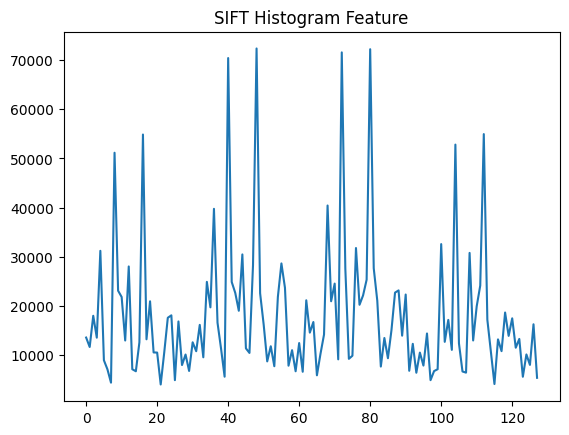

In [36]:
hist = np.sum(des, axis=0)

LeDucAnh.plot(hist)
LeDucAnh.title("SIFT Histogram Feature")
LeDucAnh.show()

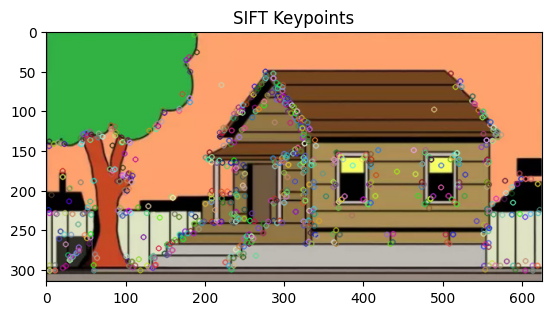

In [ ]:
img_kp = cv2.drawKeypoints(img, kp, None)# Vẽ keypoint lên ảnh gốc
LeDucAnh.imshow(img_kp[:,:,::-1]) 
LeDucAnh.title("SIFT Keypoints")
LeDucAnh.show()